# Likelihood-free inference and sums of log-normal variables

## Overall project setup

This project studies Bayesian inference for the model

$$
Y_i = \sum_{\ell=1}^{L} \exp(X_{i,\ell}),
\qquad
X_{i,\ell} \overset{iid}{\sim} \mathcal N(\mu,\sigma^2),
\qquad i=1,\dots,n.
$$

The unknown parameter is

$$
\theta = (\mu,\sigma^2).
$$

Each observation $Y_i$ is a sum of $L$ log-normal random variables.

The main difficulty is that the density of a sum of log-normal variables is not available in closed form when $L\geq 2$. Therefore the likelihood

$$
p(y^\star\mid \theta)
=
\prod_{i=1}^{n} f_Y(y_i^\star\mid \theta)
$$

cannot be evaluated directly.

This makes standard likelihood-based Bayesian inference difficult, because the posterior

$$
p(\theta\mid y^\star)
\propto
p(\theta)\,p(y^\star\mid\theta)
$$

requires the likelihood.

However, even though the likelihood is unavailable, simulation from the model is easy. Given $\theta=(\mu,\sigma^2)$, we can simulate

$$
X_{i,\ell}\sim \mathcal N(\mu,\sigma^2)
$$

and then compute

$$
Y_i = \sum_{\ell=1}^{L}\exp(X_{i,\ell}).
$$

So this is a likelihood-free inference problem.

## Structure of the full project

The project has four parts.

### Question 1: Reject-ABC

Use Reject-ABC to estimate $\theta=(\mu,\sigma^2)$.

The idea is to draw parameters from the prior, simulate fake data, compare fake data to observed data, and accept parameters whose simulated data are close enough to the observed data.

We study how the tolerance $\varepsilon$ and the prior parameters affect the result.

### Question 2: MCMC-ABC

Build an MCMC sampler that targets the same ABC posterior as in Question 1.

This may be more efficient than Reject-ABC when the prior is wide or when $\varepsilon$ is small.

### Question 3: Exact MCMC with latent variables

Introduce the latent Gaussian variables $X_{i,\ell}$.

The observed data satisfy

$$
Y_i = \sum_{\ell=1}^{L}\exp(X_{i,\ell}).
$$

By treating the $X_{i,\ell}$ as latent variables, it becomes possible to construct an exact MCMC sampler for the true posterior.

### Question 4: ABC bias

Use the exact Gibbs sampler from Question 3 as a benchmark.

Then compare ABC posterior estimates for different values of $\varepsilon$ and measure the bias introduced by the ABC approximation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 12

# Question 1 — Reject-ABC

## Goal

We want to estimate

$$
\theta = (\mu,\sigma^2)
$$

from observed data

$$
y^\star = (y_1^\star,\dots,y_n^\star).
$$

The data are generated from

$$
Y_i = \sum_{\ell=1}^{L}\exp(X_{i,\ell}),
\qquad
X_{i,\ell}\overset{iid}{\sim}\mathcal N(\mu,\sigma^2).
$$

Following the project statement, we first generate synthetic observed data from known true parameters:

$$
L=10,
\qquad
\mu_0=0,
\qquad
\sigma_0=0.3,
\qquad
\sigma_0^2 = 0.09.
$$

The goal is to check whether Reject-ABC can recover values close to $(\mu_0,\sigma_0^2) = (0,\;0.09)$.

## Why ABC is appropriate

The likelihood is unavailable because the density of

$$
Y_i = \exp(X_{i,1})+\cdots+\exp(X_{i,L})
$$

has no closed-form expression.

But simulation is easy. For any proposed parameter $\theta=(\mu,\sigma^2)$, we can simulate fake observations from the model.

This is exactly the ABC situation:

- we cannot evaluate $p(y^\star\mid\theta)$;
- we can simulate $y^{\text{sim}}\sim p(\cdot\mid\theta)$;
- we can compare $y^{\text{sim}}$ and $y^\star$ using a distance.

## ABC posterior

Reject-ABC accepts a proposed parameter when the simulated data are close to the observed data:

$$
d(y^{\text{sim}},\,y^\star)\leq \varepsilon.
$$

The ABC posterior is

$$
p_\varepsilon(\theta\mid y^\star)
\;\propto\;
p(\theta)\;
\mathbb P_\theta
\!\left[
d(Y^{\text{sim}},\,y^\star)\leq \varepsilon
\right].
$$

When $\varepsilon$ is small, the approximation is more accurate, but the acceptance rate is lower. When $\varepsilon$ is large, the algorithm accepts more often, but the ABC approximation is rougher.

## Prior

We use the prior suggested in the project:

$$
\mu \sim \mathcal N(0,s^2),
\qquad
\eta = \log(\sigma^2)\sim \mathcal N(0,t^2).
$$

The log-variance parametrization guarantees $\sigma^2 = e^\eta > 0$.

A key practical point is that the true value is

$$
\log(\sigma_0^2)=\log(0.09)\approx -2.41.
$$

So if $t$ is too small, the prior places very little probability near the true variance. This can make Reject-ABC inefficient or biased.

## Distance

The project mentions the MEWE distance from the paper by Bernton et al. (2017). Strictly speaking, MEWE is not itself a distance — it stands for minimum expected Wasserstein estimator, and refers to the point estimator obtained by minimizing the Wasserstein distance between simulated and observed data over the parameter space.

The distance underlying MEWE is the **1-Wasserstein distance**. Since our observations are one-dimensional and the simulated and observed samples have the same size $n$, it simplifies to

$$
W_1(y^{\text{sim}},\,y^\star)
\;=\;
\frac{1}{n}
\sum_{i=1}^{n}
\left|
y^{\text{sim}}_{(i)} - y^\star_{(i)}
\right|,
$$

where $y_{(i)}$ denotes the $i$-th order statistic. This compares the full empirical distributions of simulated and observed data, with no need to choose summary statistics.

Computing $W_1$ in 1D costs only $O(n\log n)$ (the cost of sorting both samples).

## Reject-ABC algorithm

The algorithm repeatedly proposes parameters from the prior, simulates fake data, and keeps the parameter if the simulated data is close enough to the observed data:

$$
\boxed{
\begin{aligned}
&\textbf{Reject-ABC} \\[4pt]
&\text{Set } \texttt{accepted} = \emptyset.\\[2pt]
&\textbf{while } |\texttt{accepted}| < N \textbf{ do:}\\
&\quad 1.\;\text{Draw } \theta^* = (\mu^*,\,\sigma^{2*}) \text{ from the prior } p(\theta).\\
&\quad 2.\;\text{Simulate fake data under } \theta^*\text{:}\\
&\qquad\qquad X^*_{i,\ell} \sim \mathcal N(\mu^*,\,\sigma^{2*}),
\quad
Z^*_i = \sum_{\ell=1}^{L}\exp(X^*_{i,\ell}),
\quad i=1,\dots,n.\\
&\quad 3.\;\text{Compute the distance } d(z^*,\,y^\star) = W_1(z^*,\,y^\star).\\
&\quad 4.\;\textbf{if } d(z^*,\,y^\star) \leq \varepsilon\text{:}\\
&\qquad\qquad \texttt{accepted} = \texttt{accepted}\cup\{\theta^*\}.\\
&\textbf{return } \texttt{accepted}.
\end{aligned}
}
$$

The accepted draws $\{\theta^{*(1)},\dots,\theta^{*(N)}\}$ form an i.i.d. sample from the ABC posterior $p_\varepsilon(\theta\mid y^\star)$.

## Implementation

We define three helper functions:
1. a simulator for the sum-of-lognormals model,
2. the 1-Wasserstein distance between two 1D samples,
3. a posterior summary table.

In [2]:
def simulate_sum_lognormal(mu, sigma2, L, n, rng):
    """Simulate n observations from Y_i = sum exp(X_{i,l}), X_{i,l} ~ N(mu, sigma2)."""
    X = rng.normal(loc=mu, scale=np.sqrt(sigma2), size=(n, L))
    return np.exp(X).sum(axis=1)


def wasserstein1d(y1, y2):
    """
    1-Wasserstein distance between two 1D samples.
    Equal sizes: W1 = mean|sorted(y1) - sorted(y2)|.
    Unequal sizes: interpolate quantile functions on a common grid.
    """
    y1 = np.sort(np.asarray(y1, dtype=float))
    y2 = np.sort(np.asarray(y2, dtype=float))
    n1, n2 = len(y1), len(y2)
    if n1 == n2:
        return np.mean(np.abs(y1 - y2))
    grid = np.linspace(0, 1, max(n1, n2), endpoint=False) + 0.5 / max(n1, n2)
    q1 = np.interp(grid, (np.arange(n1) + 0.5) / n1, y1)
    q2 = np.interp(grid, (np.arange(n2) + 0.5) / n2, y2)
    return np.mean(np.abs(q1 - q2))


def posterior_summary(accepted, true_values=None):
    """Summarize ABC posterior. accepted has columns [mu, sigma2]."""
    if len(accepted) == 0:
        raise ValueError("No accepted draws.")
    names = ["mu", "sigma2"]
    rows = []
    for j, name in enumerate(names):
        col = accepted[:, j]
        row = {
            "parameter": name,
            "mean": f"{col.mean():.4f}",
            "median": f"{np.median(col):.4f}",
            "std": f"{col.std():.4f}",
            "q2.5%": f"{np.quantile(col, 0.025):.4f}",
            "q97.5%": f"{np.quantile(col, 0.975):.4f}",
        }
        if true_values is not None:
            row["true"] = f"{true_values[j]:.4f}"
        rows.append(row)
    return pd.DataFrame(rows)

## Synthetic observed data

We generate the observed dataset from known true parameters as specified in the project.

In [3]:
n = 200
L = 10
mu_true = 0.0
sigma_true = 0.3
sigma2_true = sigma_true**2

y_obs = simulate_sum_lognormal(mu_true, sigma2_true, L, n, rng)

print(f"n = {n},  L = {L}")
print(f"mu_true = {mu_true},  sigma2_true = {sigma2_true}")
print(f"Observed data: mean = {y_obs.mean():.2f}, std = {y_obs.std():.2f}")

n = 200,  L = 10
mu_true = 0.0,  sigma2_true = 0.09
Observed data: mean = 10.36, std = 1.08


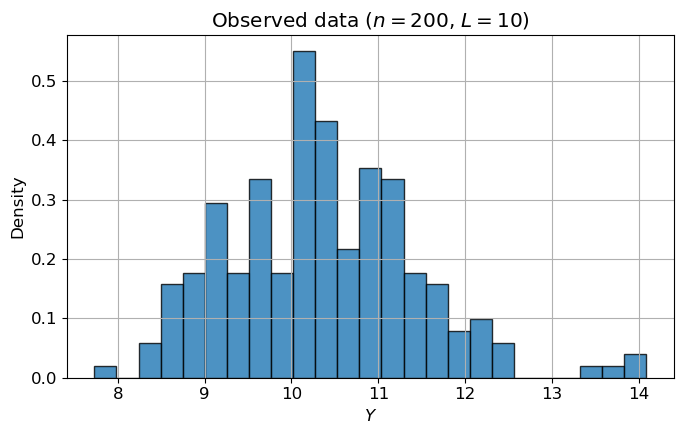

In [4]:
plt.hist(y_obs, bins=25, density=True, edgecolor="black", alpha=0.8)
plt.xlabel(r"$Y$")
plt.ylabel("Density")
plt.title(f"Observed data ($n={n}$, $L={L}$)")
plt.tight_layout()
plt.show()

In [5]:
def reject_abc(y_obs, L, epsilon, n_keep, s=1.0, t=1.0,
               max_proposals=500_000, seed=1234):
    """
    Reject-ABC for theta = (mu, sigma^2).
    Prior: mu ~ N(0, s^2), log(sigma^2) ~ N(0, t^2).
    Returns: accepted (n_accepted, 2), distances, n_proposals, acceptance_rate
    """
    rng_abc = np.random.default_rng(seed)
    n = len(y_obs)
    accepted = []
    distances = []
    proposals = 0

    while len(accepted) < n_keep and proposals < max_proposals:
        proposals += 1
        mu_star = rng_abc.normal(0.0, s)
        eta_star = rng_abc.normal(0.0, t)
        sigma2_star = np.exp(eta_star)

        y_sim = simulate_sum_lognormal(mu_star, sigma2_star, L, n, rng_abc)
        d = wasserstein1d(y_sim, y_obs)

        if d <= epsilon:
            accepted.append([mu_star, sigma2_star])
            distances.append(d)

    accepted = np.array(accepted) if accepted else np.empty((0, 2))
    rate = len(accepted) / proposals if proposals > 0 else 0.0

    if len(accepted) < n_keep:
        print(f"  Warning: only {len(accepted)}/{n_keep} accepted "
              f"after {proposals} proposals.")
    return accepted, np.array(distances), proposals, rate

## Calibrating $\varepsilon$ from the prior predictive

Before running ABC, we need a reasonable value for $\varepsilon$. A standard approach is:

1. Draw many $\theta$ from the prior.
2. Simulate fake data under each $\theta$.
3. Compute $W_1(y^{\text{sim}},\,y^\star)$ for each draw.
4. Choose $\varepsilon$ as a low quantile of the resulting distance distribution.

For instance, taking the 1% quantile means we expect roughly 1% of prior draws to be accepted. This gives a concrete estimate of the acceptance rate before committing to a long run.

In [6]:
def prior_predictive_distances(y_obs, L, s, t, n_calib=5000, seed=999):
    rng_cal = np.random.default_rng(seed)
    n = len(y_obs)
    dists = np.empty(n_calib)
    for k in range(n_calib):
        mu_ = rng_cal.normal(0.0, s)
        eta_ = rng_cal.normal(0.0, t)
        sigma2_ = np.exp(eta_)
        y_sim = simulate_sum_lognormal(mu_, sigma2_, L, n, rng_cal)
        dists[k] = wasserstein1d(y_sim, y_obs)
    return dists

# Default prior scales
s0, t0 = 1.0, 1.0

calib_dists = prior_predictive_distances(y_obs, L, s=s0, t=t0, n_calib=5000, seed=2027)

# Candidate epsilons
quantiles = [0.20, 0.10, 0.05, 0.01, 0.005]
eps_table = {q: np.quantile(calib_dists, q) for q in quantiles}

print(f"Prior predictive calibration (s={s0}, t={t0}):\n")
for q, e in eps_table.items():
    print(f"  quantile {100*q:5.1f}%  =>  epsilon = {e:.4f}")

Prior predictive calibration (s=1.0, t=1.0):

  quantile  20.0%  =>  epsilon = 4.0842
  quantile  10.0%  =>  epsilon = 2.6489
  quantile   5.0%  =>  epsilon = 1.8427
  quantile   1.0%  =>  epsilon = 0.9365
  quantile   0.5%  =>  epsilon = 0.7131


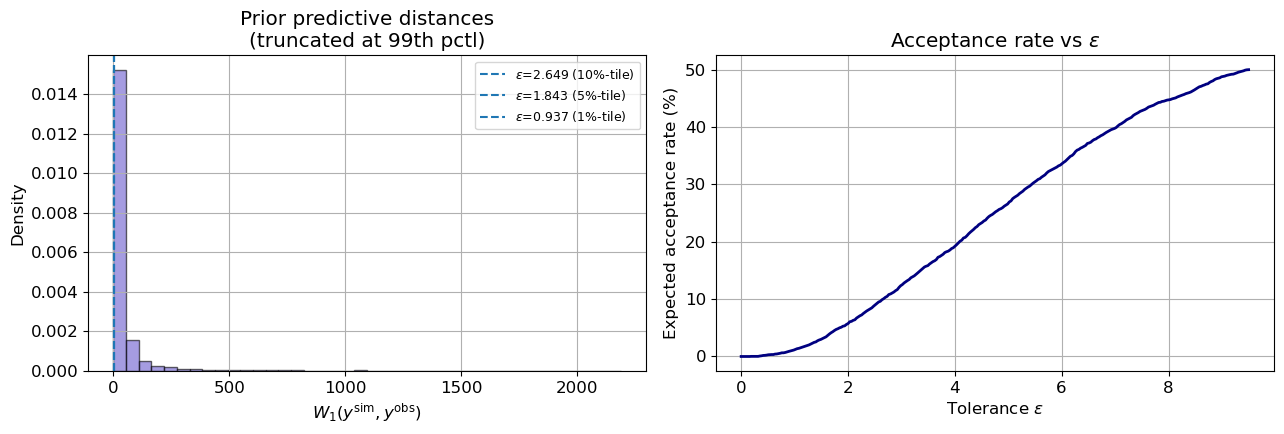

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: histogram (truncated at 99th percentile for readability)
xmax = np.quantile(calib_dists, 0.99)
axes[0].hist(calib_dists[calib_dists <= xmax], bins=40, density=True,
             alpha=0.6, edgecolor="black", color="slateblue")
for q in [0.10, 0.05, 0.01]:
    axes[0].axvline(eps_table[q], ls="--",
                    label=fr"$\varepsilon$={eps_table[q]:.3f} ({100*q:.0f}%-tile)")
axes[0].set_xlabel(r"$W_1(y^{\rm sim}, y^{\rm obs})$")
axes[0].set_ylabel("Density")
axes[0].set_title("Prior predictive distances\n(truncated at 99th pctl)")
axes[0].legend(fontsize=9)

# Right: acceptance rate curve
eps_grid = np.linspace(0, np.quantile(calib_dists, 0.50), 300)
acc_curve = [(calib_dists <= e).mean() * 100 for e in eps_grid]
axes[1].plot(eps_grid, acc_curve, lw=2, color="navy")
axes[1].set_xlabel(r"Tolerance $\varepsilon$")
axes[1].set_ylabel("Expected acceptance rate (%)")
axes[1].set_title(r"Acceptance rate vs $\varepsilon$")

plt.tight_layout()
plt.show()

The prior predictive distances are heavily right-skewed: most prior draws produce parameters far from the truth, so $W_1$ is large. Only a small fraction of draws land close enough to be accepted.

The right panel shows that, for instance, at the 1% quantile, we need about 100 proposals per accepted draw. This is computationally manageable for our setup.

## Main Reject-ABC run

We choose $\varepsilon$ as the 1% prior-predictive quantile. This is moderately strict: concentrated enough to give a meaningful posterior, but with a high enough acceptance rate to collect a good sample size.

In [8]:
eps_main = eps_table[0.01]

accepted, dists_acc, n_prop, acc_rate = reject_abc(
    y_obs, L, epsilon=eps_main, n_keep=500,
    s=s0, t=t0, max_proposals=500_000, seed=2028
)

print(f"epsilon       = {eps_main:.4f}")
print(f"accepted      = {len(accepted)}")
print(f"proposals     = {n_prop}")
print(f"accept. rate  = {acc_rate:.4f}  ({100*acc_rate:.2f}%)")
print(f"correlation   = {np.corrcoef(accepted[:,0], accepted[:,1])[0,1]:.3f}")
print()
posterior_summary(accepted, true_values=[mu_true, sigma2_true])

epsilon       = 0.9365
accepted      = 500
proposals     = 48745
accept. rate  = 0.0103  (1.03%)
correlation   = -0.665



,parameter,mean,median,std,q2.5%,q97.5%,true
0,mu,-0.0870,-0.0915,0.0656,-0.1974,0.0472,0.0000
1,sigma2,0.2375,0.2360,0.0865,0.0821,0.4044,0.0900


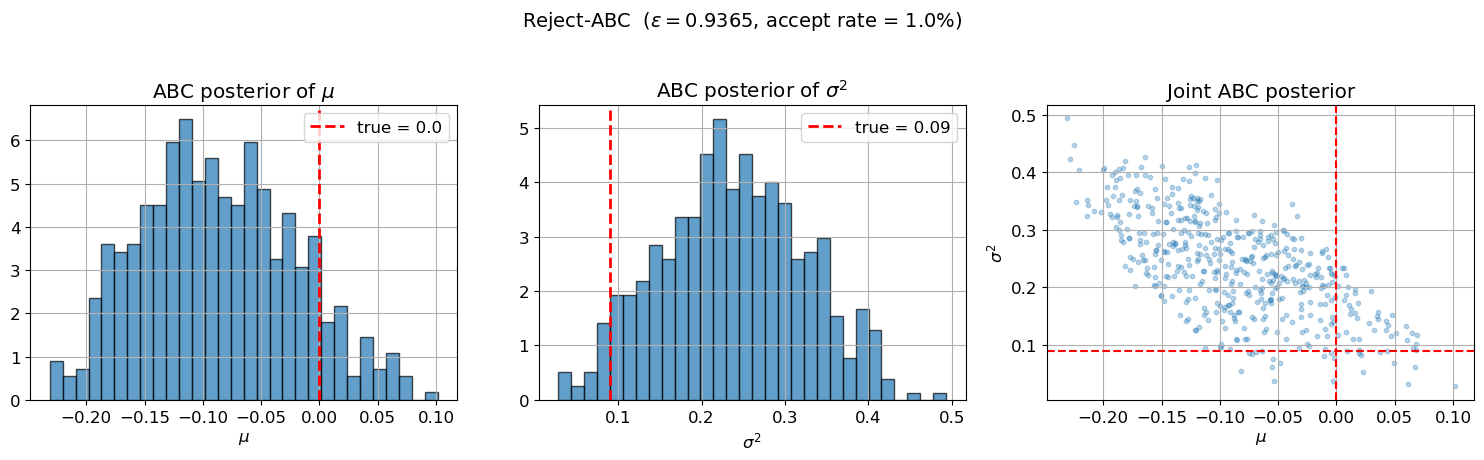

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) mu
axes[0].hist(accepted[:, 0], bins=30, density=True, edgecolor="black", alpha=0.7)
axes[0].axvline(mu_true, color="red", lw=2, ls="--", label=f"true = {mu_true}")
axes[0].set_xlabel(r"$\mu$")
axes[0].set_title(r"ABC posterior of $\mu$")
axes[0].legend()

# (b) sigma^2
axes[1].hist(accepted[:, 1], bins=30, density=True, edgecolor="black", alpha=0.7)
axes[1].axvline(sigma2_true, color="red", lw=2, ls="--", label=f"true = {sigma2_true}")
axes[1].set_xlabel(r"$\sigma^2$")
axes[1].set_title(r"ABC posterior of $\sigma^2$")
axes[1].legend()

# (c) joint
axes[2].scatter(accepted[:, 0], accepted[:, 1], s=10, alpha=0.3)
axes[2].axvline(mu_true, color="red", ls="--")
axes[2].axhline(sigma2_true, color="red", ls="--")
axes[2].set_xlabel(r"$\mu$")
axes[2].set_ylabel(r"$\sigma^2$")
axes[2].set_title(r"Joint ABC posterior")

plt.suptitle(fr"Reject-ABC  ($\varepsilon = {eps_main:.4f}$, accept rate = {100*acc_rate:.1f}%)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observations from the main run** ($\varepsilon \approx 0.94$, acceptance rate $\approx 1\%$):

The ABC posterior mean for $\mu$ is around $-0.09$, slightly below the true value $\mu_0 = 0$. The 95% credible interval does contain the true value, but the posterior is shifted to the left. This small negative bias on $\mu$ is linked to the strong **negative correlation** ($\rho \approx -0.67$) between $\mu$ and $\sigma^2$ in the joint posterior: the model can produce similar data by increasing $\sigma^2$ and decreasing $\mu$ (or vice versa), because both parameters affect the overall scale of $Y_i = \sum \exp(X_{i,\ell})$.

The more striking finding is for $\sigma^2$: the posterior mean is around $0.24$, which is more than twice the true value $\sigma^2_0 = 0.09$. The 95% credible interval does cover the truth, but the distribution is clearly centered too high. This upward bias comes from the prior: since $\log\sigma^2 \sim \mathcal{N}(0,1)$, the prior is centered at $\sigma^2 = 1$, which pulls the posterior away from the true value. With $\varepsilon$ at the 1% quantile, the ABC tolerance is not strict enough to fully overcome this prior pull.

## Effect of $\varepsilon$

We now run Reject-ABC for several tolerance levels and compare the results.

As $\varepsilon$ decreases, we expect:
- the posterior to become more concentrated,
- the posterior mean to move closer to the true value (less ABC bias),
- the acceptance rate to drop (higher computational cost).

In [10]:
eps_levels = [
    (0.20, "q=20%"),
    (0.10, "q=10%"),
    (0.01, "q=1%"),
    (0.005, "q=0.5%"),
]

eps_results = []
for j, (q, label) in enumerate(eps_levels):
    eps_val = eps_table[q]
    acc_j, _, nprop_j, rate_j = reject_abc(
        y_obs, L, epsilon=float(eps_val), n_keep=400,
        s=s0, t=t0, max_proposals=500_000, seed=3000 + j
    )
    eps_results.append({
        "quantile": label, "epsilon": eps_val,
        "n_accepted": len(acc_j), "n_proposals": nprop_j,
        "acc_rate": rate_j, "samples": acc_j,
    })

# Summary table
summary_rows = []
for r in eps_results:
    row = {
        "quantile": r["quantile"],
        "epsilon": f'{r["epsilon"]:.4f}',
        "accepted": r["n_accepted"],
        "proposals": r["n_proposals"],
        "acc. rate (%)": f'{100*r["acc_rate"]:.2f}',
    }
    if len(r["samples"]):
        row["E[mu]"] = f'{r["samples"][:, 0].mean():.4f}'
        row["E[sigma2]"] = f'{r["samples"][:, 1].mean():.4f}'
    else:
        row["E[mu]"] = chr(8212)
        row["E[sigma2]"] = chr(8212)
    summary_rows.append(row)

print(pd.DataFrame(summary_rows).to_string(index=False))

quantile epsilon  accepted  proposals acc. rate (%)   E[mu] E[sigma2]
   q=20%  4.0842       400       2006         19.94 -0.3915    0.7075
   q=10%  2.6489       400       4061          9.85 -0.2416    0.5139
    q=1%  0.9365       400      39333          1.02 -0.0843    0.2349
  q=0.5%  0.7131       400      74087          0.54 -0.0661    0.1983


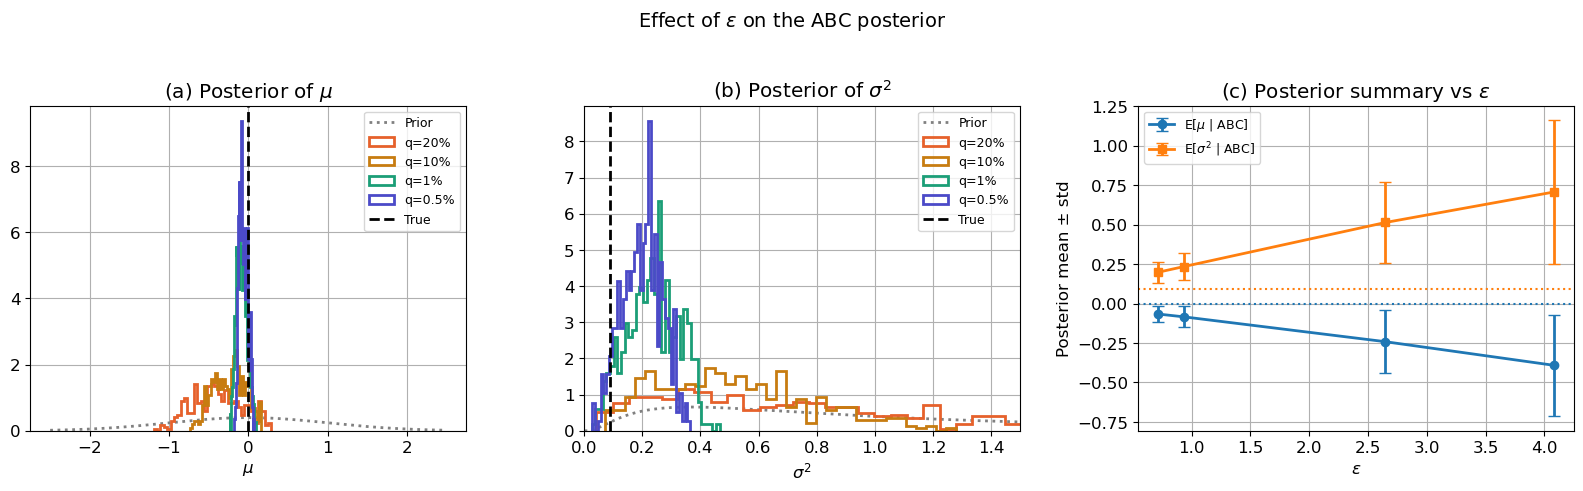

In [11]:
colors = ["#E6612B", "#C77C11", "#1B9E77", "#4B4AC8"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# --- (a) Posterior of mu ---
x_mu = np.linspace(-2.5, 2.5, 300)
prior_mu = (1 / (np.sqrt(2*np.pi) * s0)) * np.exp(-0.5 * (x_mu / s0)**2)
axes[0].plot(x_mu, prior_mu, ":", color="gray", lw=2, label="Prior")
for r, c in zip(eps_results, colors):
    if len(r["samples"]):
        axes[0].hist(r["samples"][:, 0], bins=35, density=True, histtype="step",
                     lw=2, color=c, label=r["quantile"])
axes[0].axvline(mu_true, color="black", lw=2, ls="--", label="True")
axes[0].set_xlabel(r"$\mu$")
axes[0].set_title(r"(a) Posterior of $\mu$")
axes[0].legend(fontsize=9)

# --- (b) Posterior of sigma^2 ---
x_s2 = np.linspace(0.001, 2.0, 400)
eta_pdf = (1 / (np.sqrt(2*np.pi) * t0)) * np.exp(-0.5 * (np.log(x_s2) / t0)**2)
prior_s2 = eta_pdf / x_s2
axes[1].plot(x_s2, prior_s2, ":", color="gray", lw=2, label="Prior")
for r, c in zip(eps_results, colors):
    if len(r["samples"]):
        axes[1].hist(r["samples"][:, 1], bins=35, density=True, histtype="step",
                     lw=2, color=c, label=r["quantile"])
axes[1].axvline(sigma2_true, color="black", lw=2, ls="--", label="True")
axes[1].set_xlim(0, 1.5)
axes[1].set_xlabel(r"$\sigma^2$")
axes[1].set_title(r"(b) Posterior of $\sigma^2$")
axes[1].legend(fontsize=9)

# --- (c) Posterior mean +/- std vs epsilon ---
for j, (param, idx, true_val) in enumerate([(r"$\mu$", 0, mu_true),
                                             (r"$\sigma^2$", 1, sigma2_true)]):
    ev = [r["epsilon"] for r in eps_results if len(r["samples"])]
    means = [r["samples"][:, idx].mean() for r in eps_results if len(r["samples"])]
    stds = [r["samples"][:, idx].std() for r in eps_results if len(r["samples"])]
    axes[2].errorbar(ev, means, yerr=stds, marker="os"[j], lw=2, capsize=4,
                     label=f"E[{param} | ABC]")
    axes[2].axhline(true_val, ls=":", lw=1.5, color=f"C{j}")
axes[2].set_xlabel(r"$\varepsilon$")
axes[2].set_ylabel("Posterior mean " + chr(177) + " std")
axes[2].set_title(r"(c) Posterior summary vs $\varepsilon$")
axes[2].legend(fontsize=9)

plt.suptitle(r"Effect of $\varepsilon$ on the ABC posterior", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observations on the effect of $\varepsilon$:**

As $\varepsilon$ decreases, the posterior concentrates and moves toward the true values, as expected.

For large $\varepsilon$ (20% quantile), the ABC posterior is barely more informative than the prior: $\hat{E}[\sigma^2] \approx 0.71$, far from the true $0.09$. For the strictest tolerance (0.5% quantile), $\hat{E}[\sigma^2]$ drops to about $0.20$, which is better but still more than double the true value.

This persistent bias has two sources:
1. **ABC approximation bias** from finite $\varepsilon$: with $\varepsilon > 0$, we accept parameters that produce data only approximately matching $y^\star$.
2. **Prior influence**: the prior on $\log\sigma^2$ is centered at $\sigma^2 = 1$, far above the truth. Even a moderately strict tolerance cannot fully overcome this prior mismatch.

The bias shrinks as $\varepsilon$ decreases (from $\hat{E}[\sigma^2]\approx 0.71$ down to $\approx 0.20$), but convergence is slow. This motivates exploring a better prior (see below) or switching to MCMC-ABC to push $\varepsilon$ even lower.

## Sensitivity to the prior scales $s$ and $t$

The project asks us to discuss the impact of $s$ (prior width on $\mu$) and $t$ (prior width on $\log\sigma^2$).

We fix $\varepsilon$ at its main value and vary each scale separately.

**Intuition:**

- A wide prior wastes proposals on implausible parameter regions, lowering the acceptance rate.
- A tight prior can bias the posterior if it does not cover the true value.
- We expect sensitivity to $t$ to be stronger than to $s$, because the prior on $\log\sigma^2$ is centered at 0 (i.e. $\sigma^2=1$), which is far from the true $\log(0.09)\approx -2.41$.

In [12]:
# --- Vary s (prior width on mu), keep t fixed ---
s_grid = [0.3, 1.0, 3.0]
s_runs = []
for j, s_try in enumerate(s_grid):
    acc_s, _, _, rate_s = reject_abc(
        y_obs, L, epsilon=eps_main, n_keep=300,
        s=s_try, t=t0, max_proposals=500_000, seed=4000 + j
    )
    s_runs.append((s_try, acc_s, rate_s))

# --- Vary t (prior width on log sigma^2), keep s fixed ---
t_grid = [0.3, 1.0, 3.0]
t_runs = []
for j, t_try in enumerate(t_grid):
    acc_t, _, _, rate_t = reject_abc(
        y_obs, L, epsilon=eps_main, n_keep=300,
        s=s0, t=t_try, max_proposals=500_000, seed=5000 + j
    )
    t_runs.append((t_try, acc_t, rate_t))

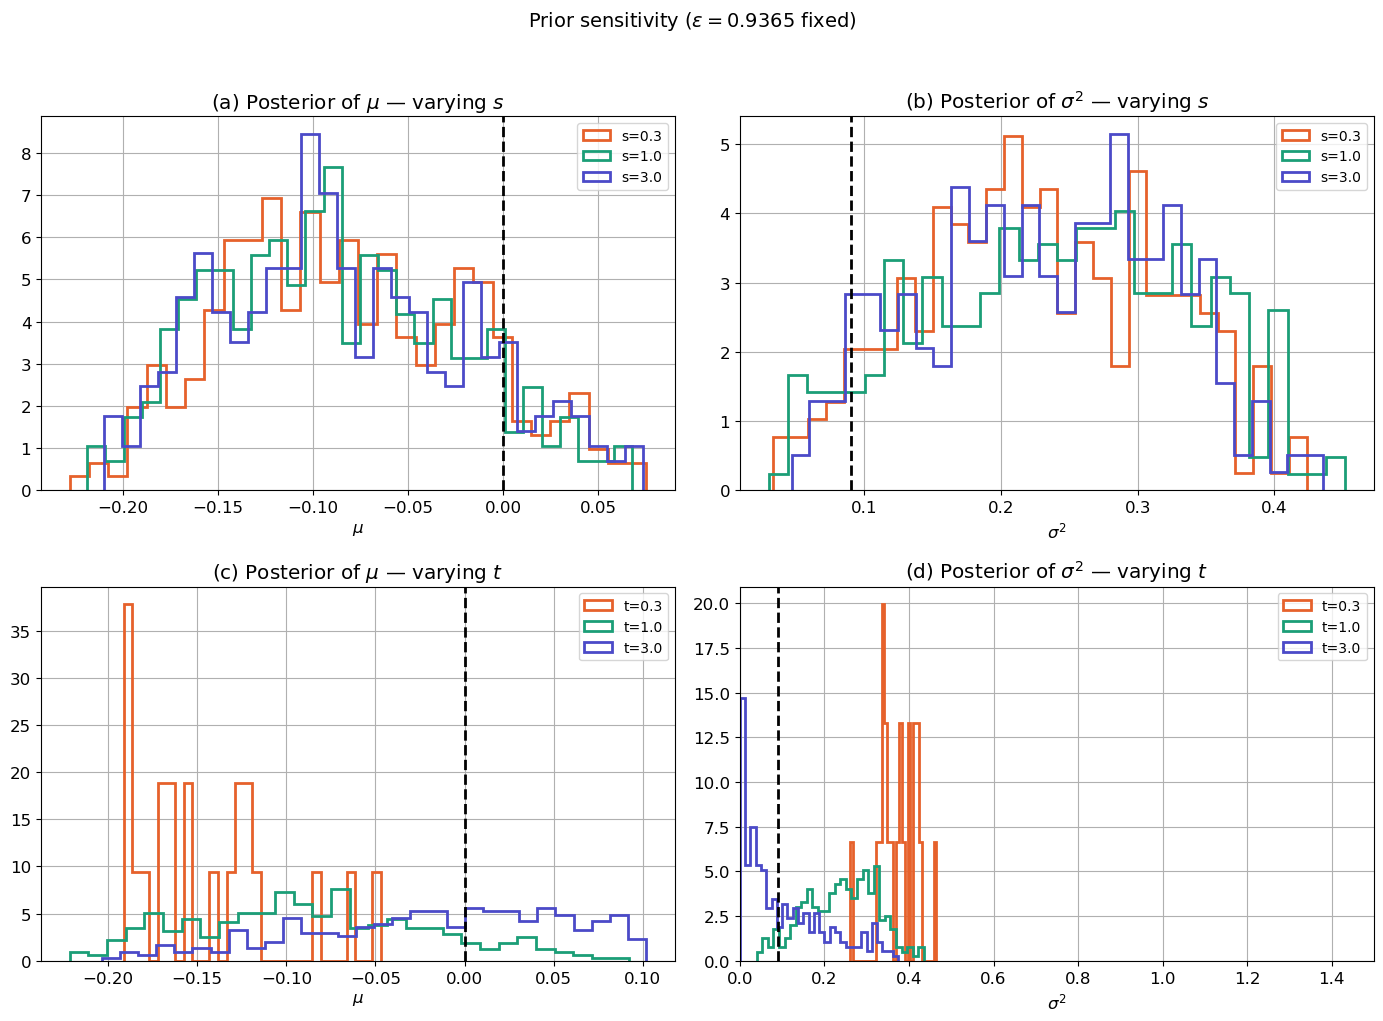

Acceptance rates:

  Varying s (t fixed at 1.0):
    s = 0.3  =>  3.31%
    s = 1.0  =>  0.92%
    s = 3.0  =>  0.34%

  Varying t (s fixed at 1.0):
    t = 0.3  =>  0.00%
    t = 1.0  =>  1.03%
    t = 3.0  =>  2.50%


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cs = ["#E6612B", "#1B9E77", "#4B4AC8"]

# ---- Row 1: varying s ----
for (s_try, acc_s, _), c in zip(s_runs, cs):
    if len(acc_s):
        axes[0, 0].hist(acc_s[:, 0], bins=30, density=True, histtype="step",
                        lw=2, color=c, label=f"s={s_try}")
axes[0, 0].axvline(mu_true, color="black", ls="--", lw=2)
axes[0, 0].set_title(r"(a) Posterior of $\mu$ — varying $s$")
axes[0, 0].set_xlabel(r"$\mu$"); axes[0, 0].legend(fontsize=10)

for (s_try, acc_s, _), c in zip(s_runs, cs):
    if len(acc_s):
        axes[0, 1].hist(acc_s[:, 1], bins=30, density=True, histtype="step",
                        lw=2, color=c, label=f"s={s_try}")
axes[0, 1].axvline(sigma2_true, color="black", ls="--", lw=2)
axes[0, 1].set_title(r"(b) Posterior of $\sigma^2$ — varying $s$")
axes[0, 1].set_xlabel(r"$\sigma^2$"); axes[0, 1].legend(fontsize=10)

# ---- Row 2: varying t ----
for (t_try, acc_t, _), c in zip(t_runs, cs):
    if len(acc_t):
        axes[1, 0].hist(acc_t[:, 0], bins=30, density=True, histtype="step",
                        lw=2, color=c, label=f"t={t_try}")
axes[1, 0].axvline(mu_true, color="black", ls="--", lw=2)
axes[1, 0].set_title(r"(c) Posterior of $\mu$ — varying $t$")
axes[1, 0].set_xlabel(r"$\mu$"); axes[1, 0].legend(fontsize=10)

for (t_try, acc_t, _), c in zip(t_runs, cs):
    if len(acc_t):
        axes[1, 1].hist(acc_t[:, 1], bins=30, density=True, histtype="step",
                        lw=2, color=c, label=f"t={t_try}")
axes[1, 1].axvline(sigma2_true, color="black", ls="--", lw=2)
axes[1, 1].set_xlim(0, 1.5)
axes[1, 1].set_title(r"(d) Posterior of $\sigma^2$ — varying $t$")
axes[1, 1].set_xlabel(r"$\sigma^2$"); axes[1, 1].legend(fontsize=10)

plt.suptitle(fr"Prior sensitivity ($\varepsilon = {eps_main:.4f}$ fixed)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Acceptance rates
print("Acceptance rates:\n")
print(f"  Varying s (t fixed at {t0:.1f}):")
for s_try, _, rate in s_runs:
    print(f"    s = {s_try:.1f}  =>  {100*rate:.2f}%")
print(f"\n  Varying t (s fixed at {s0:.1f}):")
for t_try, _, rate in t_runs:
    print(f"    t = {t_try:.1f}  =>  {100*rate:.2f}%")

**Observations on prior sensitivity:**

**Varying $s$ (prior width on $\mu$, with $t = 1$ fixed):**

The posterior is almost identical across the three values of $s$. The posterior means and standard deviations for both $\mu$ and $\sigma^2$ barely change. The only difference is the acceptance rate, which drops from about 3% ($s=0.3$) to about 0.3% ($s=3.0$) as the prior on $\mu$ gets wider: more proposals are wasted in extreme regions. Since the prior is centered at the true value $\mu_0 = 0$, widening it doesn't introduce bias — it only hurts efficiency.

**Varying $t$ (prior width on $\log\sigma^2$, with $s = 1$ fixed):**

This is where the results are most interesting.

With $t = 0.3$ (tight prior), the algorithm nearly fails: only about 20 draws are accepted out of 500,000 proposals. The prior $\log\sigma^2 \sim \mathcal{N}(0, 0.09)$ concentrates $\sigma^2$ tightly around 1, so almost no probability mass reaches the true value $\sigma^2_0 = 0.09$ (which corresponds to $\log(0.09) \approx -2.41$, many standard deviations away). The resulting posterior is heavily biased, with $\hat{E}[\sigma^2] \approx 0.37$.

With $t = 3.0$ (wide prior), the posterior mean of $\sigma^2$ drops to about $0.11$ — close to the true $0.09$. The posterior mean of $\mu$ also improves to about $-0.02$. And **the acceptance rate is actually higher** ($\approx 2.5\%$) than with $t = 1.0$ ($\approx 1.0\%$). This may seem counterintuitive — a wider prior should waste more proposals. But here the prior center ($\sigma^2 = 1$) is far from the truth ($\sigma^2 = 0.09$), so widening the prior puts *more* mass near the truth, not less. More proposals land in the region where simulated data can match $y^\star$.

**Conclusion on the prior:** the prior on $\log\sigma^2$ is the critical hyperparameter. With the default $t = 1$, the prior is not wide enough to place sufficient mass near the true $\sigma^2 = 0.09$, causing substantial upward bias. Using $t = 3$ (or re-centering the prior closer to the truth) largely fixes this.

## Numerical error assessment

The project asks us to assess the numerical error of our estimates. We repeat Reject-ABC multiple times with different random seeds, keeping the observed data and $\varepsilon$ fixed.

The variability across repetitions measures the **Monte Carlo noise** of the algorithm, as opposed to the **ABC approximation bias** from finite $\varepsilon$.

In [14]:
n_repeats = 20
repeat_quantiles = [0.10, 0.01]

mu_box, s2_box, labels_box = [], [], []

for q in repeat_quantiles:
    eps_val = eps_table[q]
    mu_reps, s2_reps = [], []
    for r in range(n_repeats):
        acc_r, _, _, _ = reject_abc(
            y_obs, L, epsilon=float(eps_val), n_keep=200,
            s=s0, t=t0, max_proposals=300_000,
            seed=7000 + 100 * int(100 * q) + r
        )
        if len(acc_r) > 0:
            mu_reps.append(acc_r[:, 0].mean())
            s2_reps.append(acc_r[:, 1].mean())
    mu_box.append(mu_reps)
    s2_box.append(s2_reps)
    labels_box.append(f"q={100*q:.0f}%\n(" + chr(949) + f"={eps_val:.3f})")

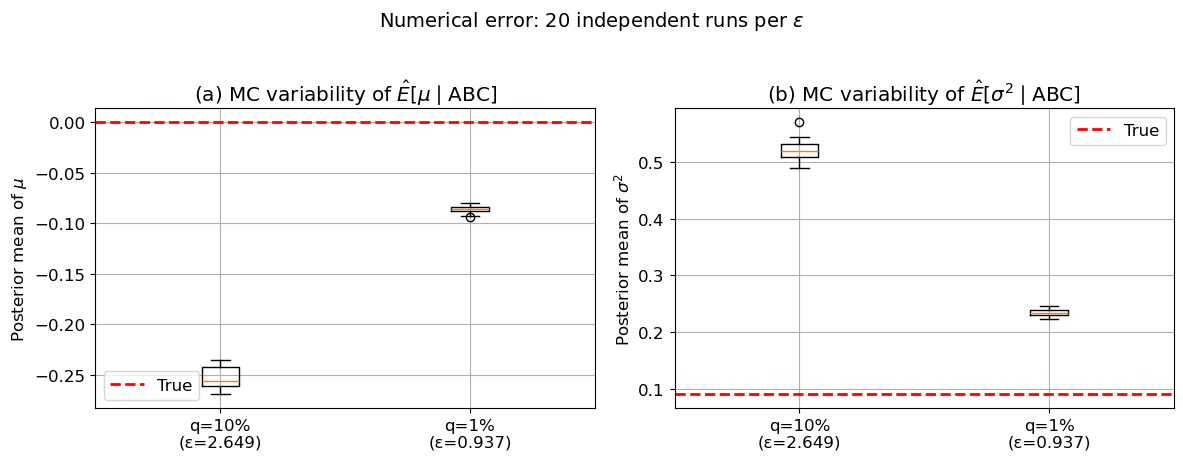

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].boxplot(mu_box, tick_labels=labels_box)
axes[0].axhline(mu_true, color="red", ls="--", lw=2, label="True")
axes[0].set_ylabel(r"Posterior mean of $\mu$")
axes[0].set_title(r"(a) MC variability of $\hat{E}[\mu \mid \mathrm{ABC}]$")
axes[0].legend()

axes[1].boxplot(s2_box, tick_labels=labels_box)
axes[1].axhline(sigma2_true, color="red", ls="--", lw=2, label="True")
axes[1].set_ylabel(r"Posterior mean of $\sigma^2$")
axes[1].set_title(r"(b) MC variability of $\hat{E}[\sigma^2 \mid \mathrm{ABC}]$")
axes[1].legend()

plt.suptitle(f"Numerical error: {n_repeats} independent runs per $\\varepsilon$",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Observations on numerical error:**

The Monte Carlo standard deviation across 20 runs is tiny compared to the ABC bias — roughly 25 times smaller for both parameters. Concretely:

- At the 10% quantile: the bias on $\sigma^2$ is about $+0.43$, while the MC standard deviation is only $0.019$.
- At the 1% quantile: the bias on $\sigma^2$ is about $+0.14$, while the MC standard deviation is only $0.006$.

This means the posterior mean estimates are highly reproducible from run to run. Running Reject-ABC again with a different seed would give nearly identical results. The dominant source of error is the ABC approximation bias from finite $\varepsilon$ (and from the prior mismatch on $\sigma^2$), not Monte Carlo noise.

The way to improve the estimates is not to increase the number of accepted draws, but to decrease $\varepsilon$ (which requires more proposals) or to use a better prior.

## Posterior predictive check

As a final diagnostic, we draw parameters from the ABC posterior, simulate new datasets under them, and compare these replicated datasets to the observed data.

If the ABC posterior is reasonable, the replicated datasets should look similar to $y^\star$.

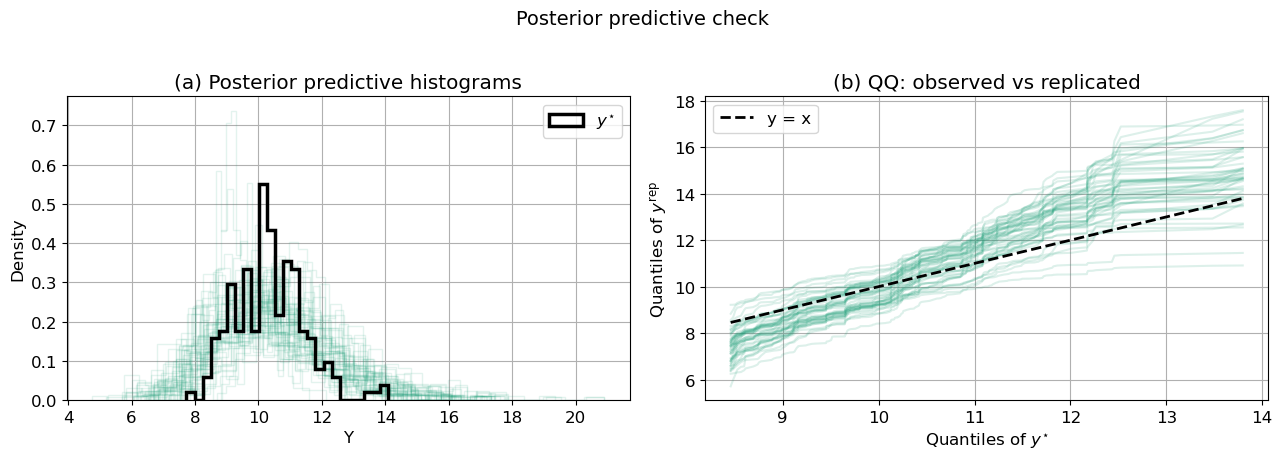

In [16]:
rng_ppc = np.random.default_rng(2029)
n_rep = 50
idx = rng_ppc.choice(len(accepted), size=n_rep, replace=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Histogram overlay
for k in idx:
    y_rep = simulate_sum_lognormal(accepted[k, 0], accepted[k, 1], L, n, rng_ppc)
    axes[0].hist(y_rep, bins=25, density=True, histtype="step",
                 color="#1b9e77", alpha=0.12)
axes[0].hist(y_obs, bins=25, density=True, histtype="step",
             color="black", lw=2.5, label=r"$y^{\star}$")
axes[0].set_xlabel("Y"); axes[0].set_ylabel("Density")
axes[0].set_title("(a) Posterior predictive histograms")
axes[0].legend()

# (b) QQ plot
q_grid = np.linspace(0.01, 0.99, n)
obs_q = np.quantile(y_obs, q_grid)
for k in idx:
    y_rep = simulate_sum_lognormal(accepted[k, 0], accepted[k, 1], L, n, rng_ppc)
    axes[1].plot(obs_q, np.quantile(y_rep, q_grid), color="#1b9e77", alpha=0.15)
lims = [obs_q.min(), obs_q.max()]
axes[1].plot(lims, lims, "k--", lw=2, label="y = x")
axes[1].set_xlabel(r"Quantiles of $y^{\star}$")
axes[1].set_ylabel(r"Quantiles of $y^{\rm rep}$")
axes[1].set_title("(b) QQ: observed vs replicated")
axes[1].legend()

plt.suptitle("Posterior predictive check", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Summary of Question 1

Reject-ABC is feasible for this model: even though the likelihood of the sum-of-lognormals model has no closed form, simulation is easy, and the 1-Wasserstein distance provides a natural discrepancy.

**On $\varepsilon$.** There is a clear bias-variance tradeoff. At large $\varepsilon$ (20%-quantile), the posterior is nearly as diffuse as the prior, with $\hat{E}[\sigma^2] \approx 0.71$ against the true $0.09$. At the strictest tolerance we tried (0.5%-quantile), $\hat{E}[\sigma^2]$ drops to about $0.20$, which is better but still more than double the truth. The bias decreases as $\varepsilon$ shrinks, but convergence is slow.

**On the prior.** The prior on $\mu$ (controlled by $s$) has essentially no effect on the posterior — only on the acceptance rate. The prior on $\log\sigma^2$ (controlled by $t$) is far more important. With the default $t = 1$, the prior centered at $\sigma^2 = 1$ is too far from the true $\sigma^2 = 0.09$, causing persistent upward bias. A wider prior ($t = 3$) dramatically improves both accuracy ($\hat{E}[\sigma^2] \approx 0.11$) and efficiency (acceptance rate rises from 1% to 2.5%), because it places more mass near the truth.

**On numerical error.** Monte Carlo variability is negligible: the standard deviation across 20 repeated runs is about 25 times smaller than the ABC bias. The bottleneck is the approximation quality, not randomness.

**Posterior predictive checks** show that, despite the bias on $\sigma^2$, the ABC posterior produces simulated datasets that visually match the observed data. This is a reminder that posterior predictive checks alone do not detect parameter bias — the model can fit the data with different parameter combinations, as suggested by the strong negative correlation ($\rho \approx -0.67$) between $\mu$ and $\sigma^2$ in the joint posterior.

A natural next step is MCMC-ABC (Question 2), which can explore smaller $\varepsilon$ values more efficiently, and the exact Gibbs sampler (Question 3), which avoids the ABC approximation entirely.